In [1]:
import scipy.io
import pprint
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
NORMALIZATION_VALUE = 300
DEFAULT_NUMBER_OF_VALUES_IN_WINDOW = 15

TRAINING_DATA_PERCENTAGE = 0.85
DEFAULT_BATCH_SIZE = 32

In [3]:
def createDataWithWindows(d, windowSize):
    windowedData = []

    for i in range(windowSize, len(d)):
        windowValues = []

        for j in range(windowSize):
            if(i - windowSize + j < 0):
                windowValues.append(0.0)
            else:
                windowValues.append(d[i - windowSize + j])

        windowedData.append([windowValues, d[i]])

    return windowedData

def saveData(d, windowSize):
    np.save('data/data_' + str(windowSize) + '.npy', np.array(d, dtype = object))

def loadData(windowSize):
    data = np.load('data/data_' + str(windowSize) + '.npy', allow_pickle = True).tolist()
    return data

def createWindowedDataFiles(d, min, max):
    for i in range(min, max):
        temp = createDataWithWindows(d, i)
        saveData(temp, i)

def printData(d):
    for item in d:
        print(item)

In [4]:
# Load data
mat = scipy.io.loadmat('Xtrain.mat')

data = mat['Xtrain']
data = data[:, 0] 
data = data / NORMALIZATION_VALUE

window_size = DEFAULT_NUMBER_OF_VALUES_IN_WINDOW

createWindowedDataFiles(data, window_size, 20)

# Example usage
data_windows = createDataWithWindows(data, DEFAULT_NUMBER_OF_VALUES_IN_WINDOW)
saveData(data_windows, DEFAULT_NUMBER_OF_VALUES_IN_WINDOW)
data_windows = loadData(DEFAULT_NUMBER_OF_VALUES_IN_WINDOW)

In [5]:
class WindowedDataset(Dataset):
    def __init__(self, data):
        self.X = torch.tensor([[item[0]] for item in data], dtype=torch.float32)
        self.y = torch.tensor([[item[1]] for item in data], dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

trainDataSet = WindowedDataset(data_windows)

trainSetSize = int(TRAINING_DATA_PERCENTAGE * len(trainDataSet))
validSetSize = len(trainDataSet) - trainSetSize
trainDataSet, validDataSet = torch.utils.data.random_split(trainDataSet, [trainSetSize, validSetSize])

trainLoader = DataLoader(trainDataSet, batch_size = DEFAULT_BATCH_SIZE, shuffle = True)
validLoader = DataLoader(validDataSet, batch_size = DEFAULT_BATCH_SIZE, shuffle = True)

In [ ]:
class CNN(torch.nn.Module):
    def __init__(self, input_size, n_filters):
        super().__init__()
        self.conv = torch.nn.Conv1d(in_channels = 1, out_channels = n_filters, kernel_size = input_size)
        self.fc1 = torch.nn.Linear(n_filters, 1)
        self.input_size = input_size

    def initialize_weights(m):
        if isinstance(m, (torch.nn.Conv2d, torch.nn.Linear)):
            torch.nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
    
    def forward(self, x):
        x = torch.nn.functional.relu(self.conv(x))
        x = torch.flatten(x, 1)
        x = torch.nn.functional.relu(self.fc1(x))

        return x

def train_model(model, train_data, n_epochs, lr, patience):
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    for epoch in range(n_epochs):
        train_loss = 0
        val_loss = 0
        num_batches = 0

        # train and update weights
        for (x, y) in trainLoader:
            x = x.to(device)
            y = y.to(device)
            predictions = model(x)
            batch_loss = criterion(predictions,y)

            optimizer.zero_grad()
            batch_loss.backward()
            optimizer.step()

            train_loss += batch_loss
            num_batches += 1

        with torch.no_grad():
            for (x, y) in trainLoader:
                x = x.to(device)
                y = y.to(device)
                predictions = model(x)
                batch_loss = criterion(predictions,y)
    
                val_loss += batch_loss
        # check for improvement on val set
        epochs_without_improvement += 1
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
        if(epoch%10 == 0):
            print(f'Epoch {epoch+1},\t training loss {train_loss/num_batches} \t validation loss {val_loss/num_batches}')

        # early stopping
        if epochs_without_improvement > patience:
            print(f'Early stopping epoch {epoch+1}, \t training loss {train_loss/num_batches} \t validation loss {val_loss/num_batches}')
            break

epochs = 300
learning_rate = 0.001
n_filters = 64
patience = 8
model = CNN(window_size, n_filters)
model.initialize_weights()
device = torch.device("cuda"if torch.cuda.is_available() else "cpu")
model.to(device)
train_model(model, trainLoader, epochs, learning_rate, patience)

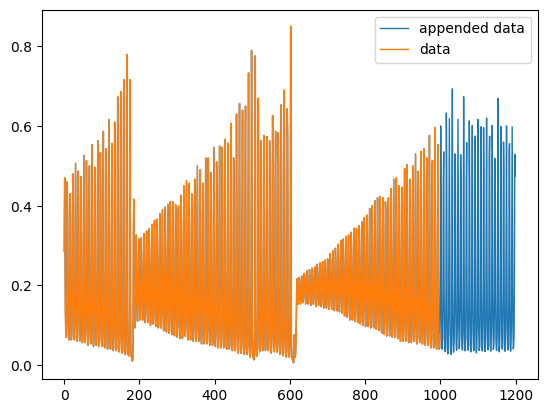

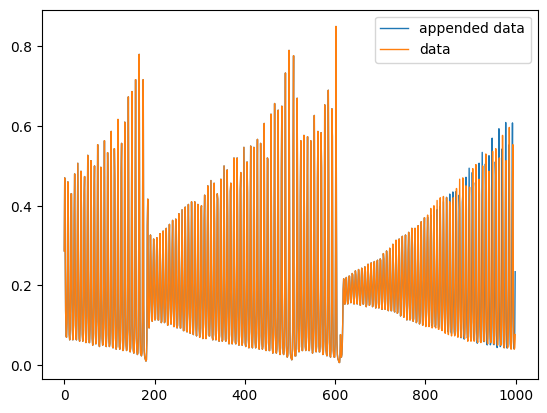

MSE: 0.009451952762901783 	 MAE: 0.06675178557634354


In [22]:
import matplotlib.pyplot as plt

def predict_next(predict_index, datapoints, model):
    input_data = torch.tensor(datapoints[predict_index-window_size:predict_index], dtype=torch.float32).reshape(1, 1, -1).to(device)
    with torch.no_grad():
        prediction = model(input_data)
    return prediction

def predict_trainset():
    indices = range(len(data))
    predictions = data[:window_size].tolist()
    for i in range(window_size, len(data)):
        pred = predict_next(i, data, model).to('cpu')
        predictions.append(pred[0, 0])
    
    plt.plot(indices, data, label='data')
    plt.plot(indices, predictions, label='predictions')
    plt.show()

def predict_next_n(n_datapoints, n_dropped, data):
    appended_data = data.tolist()
    if n_dropped > 0:
        appended_data = appended_data[:-n_dropped]
    for i in range(n_datapoints):
        pred = predict_next(len(appended_data), appended_data, model).to('cpu')
        appended_data.append(pred[0, 0])
    indices = range(len(appended_data))
    plt.plot(indices, appended_data, label='appended data', linewidth = 1)
    plt.plot(range(len(data)), data, label='data', linewidth = 1)
    plt.legend()
    plt.show()
    return appended_data

def get_MSE_MAE(data, predictions):
    n = len(data)
    sum_AE = 0
    sum_SE = 0
    for i in range(n):
        diff = abs(data[i] - predictions[i])
        sum_AE += diff
        sum_SE += diff * diff
    return sum_SE / n, sum_AE / n

predict_next_n(200, 0, data)
appended_data = predict_next_n(200, 200, data)
MSE, MAE = get_MSE_MAE(data[-200:], appended_data[-200:])
print(f'MSE: {MSE} \t MAE: {MAE}')